# Feature Engineering

This notebook converts the strongest analytical findings into a model-ready feature set. The goal is to preserve the highest-signal fraud features, apply justified transformations to raw variables, and create a small set of engineered interaction features that can improve downstream model performance.


## 1. Objectives

This notebook focuses on the following tasks:

- carry forward the strongest PCA features from the multivariate stage
- apply justified transformations to `Amount` and `Time`
- create multiple interaction features from the strongest PCA signals
- compare original and engineered feature usefulness with respect to the fraud target
- save the engineered dataset and feature list for later outlier analysis, feature selection, and modeling


## Output Guide

- **Base feature table:** shows which variables move forward from the multivariate stage.
- **Engineered feature summary:** records every created feature and the reason it exists.
- **Feature-to-target comparison table:** compares raw and engineered features using the same screening logic.
- **Engineered dataset preview:** confirms the final feature structure before later notebooks use it.
- **Feature importance comparison chart:** helps judge whether the engineered features strengthen the fraud signal.

The purpose of these outputs is to produce a defensible, model-ready dataset rather than create features blindly.


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append(str(Path("..").resolve()))

from src.config import (
    AMOUNT_COLUMN,
    ARTIFACTS_DIR,
    CLEANED_DATA_FILE,
    ENGINEERED_DATA_FILE,
    FEATURE_COLUMNS_FILE,
    PCA_COLUMNS,
    PROJECT_ROOT,
    TARGET_COLUMN,
    TIME_COLUMN,
)
from src.data.data_loader import load_cleaned_data

NOTEBOOK_TABLES_DIR = PROJECT_ROOT / "reports" / "tables" / "08_feature_engineering"
NOTEBOOK_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "08_feature_engineering"
NOTEBOOK_TABLES_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
ENGINEERED_DATA_FILE.parent.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

print("Imports OK")
print(f"  Cleaned data   : {CLEANED_DATA_FILE}")
print(f"  Engineered out : {ENGINEERED_DATA_FILE}")
print(f"  Feature list   : {FEATURE_COLUMNS_FILE}")
print(f"  Tables dir     : {NOTEBOOK_TABLES_DIR}")
print(f"  Figures dir    : {NOTEBOOK_FIGURES_DIR}")


Imports OK
  Cleaned data   : /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/data/interim/creditcard_cleaned.csv
  Engineered out : /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/data/processed/creditcard_engineered.csv
  Feature list   : /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/feature_columns.json
  Tables dir     : /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/08_feature_engineering
  Figures dir    : /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/08_feature_engineering


## 2. Load Cleaned Data


In [2]:
df = load_cleaned_data()

print("Cleaned dataset shape:", df.shape)
df.head()


Cleaned dataset shape: (283726, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Select Base Features

The base feature set follows the multivariate findings: the top 10 PCA features are retained, and `Amount` plus `Time` remain as contextual raw inputs. PCA features are kept unchanged because they are already transformed, centered, and decorrelated by the original dataset construction.


In [3]:
pca_correlations = df[[*PCA_COLUMNS, TARGET_COLUMN]].corr(numeric_only=True)[TARGET_COLUMN].drop(TARGET_COLUMN)
selected_pca_features = pca_correlations.abs().sort_values(ascending=False).head(10).index.tolist()
base_features = selected_pca_features + [TIME_COLUMN, AMOUNT_COLUMN]

base_feature_table = pd.DataFrame({
    "feature": base_features,
    "feature_type": ["PCA"] * len(selected_pca_features) + ["Raw", "Raw"],
    "correlation_with_class": [pca_correlations[f] for f in selected_pca_features] + [
        df[[TIME_COLUMN, TARGET_COLUMN]].corr(numeric_only=True).loc[TIME_COLUMN, TARGET_COLUMN],
        df[[AMOUNT_COLUMN, TARGET_COLUMN]].corr(numeric_only=True).loc[AMOUNT_COLUMN, TARGET_COLUMN],
    ],
})
base_feature_table["abs_correlation_with_class"] = base_feature_table["correlation_with_class"].abs()
base_feature_table.to_csv(NOTEBOOK_TABLES_DIR / "base_feature_set.csv", index=False)
base_feature_table


,feature,feature_type,correlation_with_class,abs_correlation_with_class
0,V17,PCA,-0.313498,0.313498
1,V14,PCA,-0.293375,0.293375
2,V12,PCA,-0.250711,0.250711
3,V10,PCA,-0.206971,0.206971
4,V16,PCA,-0.187186,0.187186
5,V3,PCA,-0.182322,0.182322
6,V7,PCA,-0.172347,0.172347
7,V11,PCA,0.149067,0.149067
8,V4,PCA,0.129326,0.129326
9,V18,PCA,-0.105340,0.105340


## 4. Apply Raw-Feature Transformations

`Amount` and `Time` remain weak standalone predictors, so this notebook transforms them instead of using them only in raw form. The aim is to make their contribution more stable and more useful for downstream modeling.


In [4]:
engineered_df = df[selected_pca_features + [TIME_COLUMN, AMOUNT_COLUMN, TARGET_COLUMN]].copy()

engineered_df["log_amount"] = np.log1p(engineered_df[AMOUNT_COLUMN])
engineered_df["time_normalized"] = engineered_df[TIME_COLUMN] / engineered_df[TIME_COLUMN].max()
engineered_df["time_day_fraction"] = (engineered_df[TIME_COLUMN] % 86400) / 86400

transformation_summary = pd.DataFrame([
    {"feature": "log_amount", "source": AMOUNT_COLUMN, "transformation": "log1p", "reason": "Reduce right skew and improve model stability"},
    {"feature": "time_normalized", "source": TIME_COLUMN, "transformation": "max scaling", "reason": "Put time on a stable 0-1 scale"},
    {"feature": "time_day_fraction", "source": TIME_COLUMN, "transformation": "modulo day fraction", "reason": "Capture position within an approximate day cycle"},
])
transformation_summary.to_csv(NOTEBOOK_TABLES_DIR / "raw_feature_transformations.csv", index=False)
transformation_summary


,feature,source,transformation,reason
0,log_amount,Amount,log1p,Reduce right skew and improve model stability
1,time_normalized,Time,max scaling,Put time on a stable 0-1 scale
2,time_day_fraction,Time,modulo day fraction,Capture position within an approximate day cycle


## 5. Create Interaction Features

The interaction features below are created from the strongest multivariate PCA signals. They are intentionally limited to a small, justified set so that the feature space grows in a controlled way.


The multivariate analysis identified `V17`, `V14`, `V12`, `V10`, and `V16` as the most interaction-worthy PCA components because they combined the strongest absolute correlations with `Class` and remained substantively connected within fraud observations. `V17`, `V14`, and `V12` formed the clearest high-signal cluster, while `V10` and `V16` extended that group with additional negative fraud-linked structure. The selected pairs therefore focus on the most credible candidates for joint fraud patterns rather than testing many weak or redundant combinations.


In [5]:
interaction_definitions = [
    ("V17_V14_interaction", "V17", "V14"),
    ("V17_V12_interaction", "V17", "V12"),
    ("V14_V12_interaction", "V14", "V12"),
    ("V17_V10_interaction", "V17", "V10"),
    ("V17_V16_interaction", "V17", "V16"),
]

interaction_reason_map = {
    "V17_V14_interaction": "V17 and V14 are the two strongest negative fraud-correlated PCA features, so their interaction tests whether joint downward movement sharpens fraud separation.",
    "V17_V12_interaction": "V17 and V12 both show strong negative relationships with fraud and remain highly aligned within fraud cases, so this interaction targets a concentrated shared fraud signal.",
    "V14_V12_interaction": "V14 and V12 each carry strong negative fraud signal and are strongly positively associated in fraud observations, making their product a useful joint risk-strength feature.",
    "V17_V10_interaction": "V17 and V10 both rank among the strongest negative fraud-linked components, and their strong fraud-class association suggests a meaningful combined anomaly pattern.",
    "V17_V16_interaction": "V17 and V16 move together most strongly within fraud cases while both remain negatively related to the class label, so their interaction checks for an amplified fraud-specific PCA pattern.",
}

interaction_rows = []
for feature_name, feature_a, feature_b in interaction_definitions:
    engineered_df[feature_name] = engineered_df[feature_a] * engineered_df[feature_b]
    interaction_rows.append({
        "engineered_feature": feature_name,
        "feature_a": feature_a,
        "feature_b": feature_b,
        "reason": interaction_reason_map[feature_name],
    })

interaction_summary = pd.DataFrame(interaction_rows)
interaction_summary.to_csv(NOTEBOOK_TABLES_DIR / "interaction_feature_summary.csv", index=False)
interaction_summary


,engineered_feature,feature_a,feature_b,reason
0,V17_V14_interaction,V17,V14,V17 and V14 are the two strongest negative fra...
1,V17_V12_interaction,V17,V12,V17 and V12 both show strong negative relation...
2,V14_V12_interaction,V14,V12,V14 and V12 each carry strong negative fraud s...
3,V17_V10_interaction,V17,V10,V17 and V10 both rank among the strongest nega...
4,V17_V16_interaction,V17,V16,V17 and V16 move together most strongly within...


## 5b. Create Ratio and Magnitude Features

Fraud detection often benefits from features that express transaction size relative to a typical baseline rather than only in absolute terms. Ratio and magnitude features help distinguish transactions that are unusually large for the dataset context and test whether amount-based intensity becomes more informative when combined with a strong fraud-linked PCA signal.


In [6]:
ratio_feature_names = [
    "amount_to_mean_ratio",
    "amount_to_median_ratio",
    "amount_V17_interaction",
]

amount_mean = engineered_df[AMOUNT_COLUMN].mean()
amount_median = engineered_df[AMOUNT_COLUMN].median()

engineered_df["amount_to_mean_ratio"] = engineered_df[AMOUNT_COLUMN] / amount_mean
engineered_df["amount_to_median_ratio"] = engineered_df[AMOUNT_COLUMN] / amount_median
engineered_df["amount_V17_interaction"] = engineered_df["log_amount"] * engineered_df["V17"]

ratio_reason_map = {
    "amount_to_mean_ratio": "This ratio tests whether transactions far above the dataset average amount carry elevated fraud risk by expressing raw amount as a relative magnitude signal.",
    "amount_to_median_ratio": "This ratio anchors transaction size to the more robust median baseline, which can highlight unusually large payments without being dominated by the extreme right tail of Amount.",
    "amount_V17_interaction": "This interaction checks whether transaction magnitude becomes more informative when combined with V17, the strongest fraud-linked PCA feature, to capture high-value anomalous behavior.",
}

ratio_summary = pd.DataFrame([
    {
        "engineered_feature": "amount_to_mean_ratio",
        "source": AMOUNT_COLUMN,
        "transformation": "amount divided by dataset mean",
        "reason": ratio_reason_map["amount_to_mean_ratio"],
    },
    {
        "engineered_feature": "amount_to_median_ratio",
        "source": AMOUNT_COLUMN,
        "transformation": "amount divided by dataset median",
        "reason": ratio_reason_map["amount_to_median_ratio"],
    },
    {
        "engineered_feature": "amount_V17_interaction",
        "source": f"log_amount x V17",
        "transformation": "log amount multiplied by strongest fraud PCA signal",
        "reason": ratio_reason_map["amount_V17_interaction"],
    },
])
ratio_summary.to_csv(NOTEBOOK_TABLES_DIR / "ratio_feature_summary.csv", index=False)

feature_category_map = {
    **{feature: "PCA" for feature in selected_pca_features},
    TIME_COLUMN: "RAW",
    AMOUNT_COLUMN: "RAW",
    "time_normalized": "NORMALIZED",
    "time_day_fraction": "NORMALIZED",
    "log_amount": "LOG",
    **{feature: "RATIO" for feature in ratio_feature_names},
    **{feature_name: "INTERACTION" for feature_name, _, _ in interaction_definitions},
}

feature_category_summary = pd.DataFrame([
    {"feature": feature, "feature_category": feature_category_map[feature]}
    for feature in [*selected_pca_features, TIME_COLUMN, AMOUNT_COLUMN, "log_amount", "time_normalized", "time_day_fraction", *ratio_feature_names, *[row[0] for row in interaction_definitions]]
]).sort_values(["feature_category", "feature"])
feature_category_summary.to_csv(NOTEBOOK_TABLES_DIR / "feature_category_summary.csv", index=False)
ratio_summary


,engineered_feature,source,transformation,reason
0,amount_to_mean_ratio,Amount,amount divided by dataset mean,This ratio tests whether transactions far abov...
1,amount_to_median_ratio,Amount,amount divided by dataset median,This ratio anchors transaction size to the mor...
2,amount_V17_interaction,log_amount x V17,log amount multiplied by strongest fraud PCA s...,This interaction checks whether transaction ma...


## 6. Review Engineered Feature Usefulness

This section compares the screening relationship of the engineered features with the fraud target. These correlation values are not the final feature-selection rule, but they help verify whether the engineered features are reasonable candidates for the next stages.


In [7]:
engineered_feature_names = [
    "log_amount",
    "time_normalized",
    "time_day_fraction",
    *ratio_feature_names,
    *[row[0] for row in interaction_definitions],
]

engineered_feature_screening = engineered_df[engineered_feature_names + [TARGET_COLUMN]].corr(numeric_only=True)[[TARGET_COLUMN]].drop(index=TARGET_COLUMN)
engineered_feature_screening = engineered_feature_screening.rename(columns={TARGET_COLUMN: "correlation_with_class"}).sort_values("correlation_with_class", key=lambda s: s.abs(), ascending=False)
engineered_feature_screening["abs_correlation_with_class"] = engineered_feature_screening["correlation_with_class"].abs()
engineered_feature_screening["feature_category"] = engineered_feature_screening.index.map(feature_category_map)
engineered_feature_screening.to_csv(NOTEBOOK_TABLES_DIR / "engineered_feature_screening.csv")
engineered_feature_screening


,correlation_with_class,abs_correlation_with_class,feature_category
V14_V12_interaction,0.571907,0.571907,INTERACTION
V17_V16_interaction,0.531441,0.531441,INTERACTION
V17_V12_interaction,0.529994,0.529994,INTERACTION
V17_V14_interaction,0.528260,0.528260,INTERACTION
V17_V10_interaction,0.518306,0.518306,INTERACTION
amount_V17_interaction,-0.283188,0.283188,RATIO
time_day_fraction,-0.016696,0.016696,NORMALIZED
time_normalized,-0.012359,0.012359,NORMALIZED
log_amount,-0.007798,0.007798,LOG
amount_to_median_ratio,0.005777,0.005777,RATIO


In [8]:
comparison_rows = []
for feature in selected_pca_features[:5] + [TIME_COLUMN, AMOUNT_COLUMN] + engineered_feature_names:
    corr_value = engineered_df[[feature, TARGET_COLUMN]].corr(numeric_only=True).loc[feature, TARGET_COLUMN]
    comparison_rows.append({
        "feature": feature,
        "correlation_with_class": corr_value,
        "abs_correlation_with_class": abs(corr_value),
        "feature_group": "engineered" if feature in engineered_feature_names else "original",
        "feature_category": feature_category_map[feature],
    })

feature_comparison = pd.DataFrame(comparison_rows).sort_values("abs_correlation_with_class", ascending=False)
feature_comparison.to_csv(NOTEBOOK_TABLES_DIR / "feature_comparison_summary.csv", index=False)
feature_comparison


,feature,correlation_with_class,abs_correlation_with_class,feature_group,feature_category
15,V14_V12_interaction,0.571907,0.571907,engineered,INTERACTION
17,V17_V16_interaction,0.531441,0.531441,engineered,INTERACTION
14,V17_V12_interaction,0.529994,0.529994,engineered,INTERACTION
13,V17_V14_interaction,0.528260,0.528260,engineered,INTERACTION
16,V17_V10_interaction,0.518306,0.518306,engineered,INTERACTION
0,V17,-0.313498,0.313498,original,PCA
1,V14,-0.293375,0.293375,original,PCA
12,amount_V17_interaction,-0.283188,0.283188,engineered,RATIO
2,V12,-0.250711,0.250711,original,PCA
3,V10,-0.206971,0.206971,original,PCA


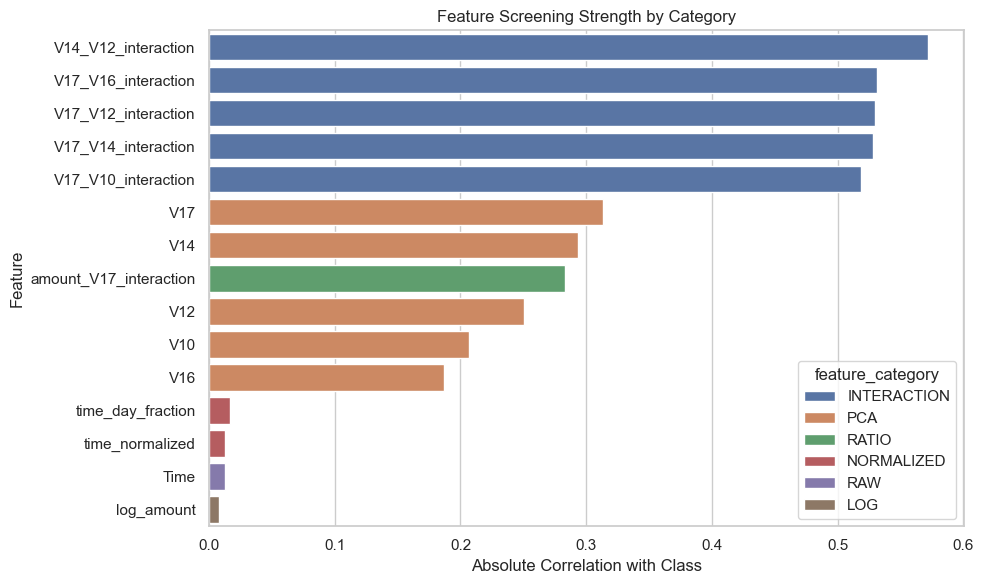

In [9]:
plot_df = feature_comparison.head(15).copy()

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="abs_correlation_with_class", y="feature", hue="feature_category")
plt.title("Feature Screening Strength by Category")
plt.xlabel("Absolute Correlation with Class")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(NOTEBOOK_FIGURES_DIR / "feature_engineering_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. Build Final Engineered Dataset

The final engineered dataset keeps the selected PCA features, preserves the raw contextual variables, and appends the retained transformed and interaction-based features created in this notebook. The exploratory `time_normalized` column is not stored in the final feature sheet because scale-based normalization should be fit later during modeling on the training split only.


In [10]:
final_feature_columns = [
    *selected_pca_features,
    TIME_COLUMN,
    AMOUNT_COLUMN,
    "log_amount",
    "time_day_fraction",
    *ratio_feature_names,
    *[row[0] for row in interaction_definitions],
]

final_engineered_df = engineered_df[final_feature_columns + [TARGET_COLUMN]].copy()
final_engineered_df.to_csv(ENGINEERED_DATA_FILE, index=False)
FEATURE_COLUMNS_FILE.write_text(json.dumps(final_feature_columns, indent=2), encoding="utf-8")
(NOTEBOOK_TABLES_DIR / "final_feature_categories.json").write_text(
    json.dumps({feature: feature_category_map[feature] for feature in final_feature_columns}, indent=2),
    encoding="utf-8",
)

print("Engineered dataset saved to:", ENGINEERED_DATA_FILE)
print("Feature columns saved to:", FEATURE_COLUMNS_FILE)
print("Final engineered dataset shape:", final_engineered_df.shape)
final_engineered_df.head()


Engineered dataset saved to: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/data/processed/creditcard_engineered.csv
Feature columns saved to: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/feature_columns.json
Final engineered dataset shape: (283726, 23)


,V17,V14,V12,V10,V16,V3,V7,V11,V4,V18,...,time_day_fraction,amount_to_mean_ratio,amount_to_median_ratio,amount_V17_interaction,V17_V14_interaction,V17_V12_interaction,V14_V12_interaction,V17_V10_interaction,V17_V16_interaction,Class
0,0.207971,-0.311169,-0.617801,0.090794,-0.470401,2.536347,0.239599,-0.551600,1.378155,0.025791,...,0.000000,1.691143,6.800909,1.042926,-0.064714,-0.128485,0.192241,0.018883,-0.097830,0
1,-0.114805,-0.143772,1.065235,-0.166974,0.463917,0.166480,-0.078803,1.612727,0.448154,-0.183361,...,0.000000,0.030405,0.122273,-0.149892,0.016506,-0.122294,-0.153151,0.019169,-0.053260,0
2,1.109969,-0.165946,0.066084,0.207643,-2.890083,1.773209,0.791461,0.624501,0.379780,-0.121359,...,0.000012,4.279965,17.211818,6.592415,-0.184195,0.073351,-0.010966,0.230477,-3.207904,0
3,-0.684093,-0.287924,0.178228,-0.054952,-1.059647,1.792993,0.237609,-0.226487,-0.863291,1.965775,...,0.000012,1.395911,5.613636,-3.300273,0.196967,-0.121925,-0.051316,0.037592,0.724897,0
4,-0.237033,-1.119670,0.538196,0.753074,-0.451449,1.548718,0.592941,-0.822843,0.403034,-0.038195,...,0.000023,0.791092,3.181364,-1.010363,0.265399,-0.127570,-0.602601,-0.178504,0.107008,0


## 8. Engineered Dataset Quality Check


In [11]:
quality_summary = pd.DataFrame({
    "metric": ["rows", "columns", "missing_values", "duplicate_rows"],
    "value": [
        final_engineered_df.shape[0],
        final_engineered_df.shape[1],
        int(final_engineered_df.isna().sum().sum()),
        int(final_engineered_df.duplicated().sum()),
    ],
})
quality_summary.to_csv(NOTEBOOK_TABLES_DIR / "engineered_dataset_quality_summary.csv", index=False)
quality_summary


,metric,value
0,rows,283726
1,columns,23
2,missing_values,0
3,duplicate_rows,0


## 9. Feature Engineering Interpretation

- The strongest PCA features are retained unchanged because they already represent the most stable and informative transformed signals in the dataset.
- `Amount` and `Time` are not discarded; instead, they are reviewed through log and time-derived transformations while the raw variables are preserved for downstream modeling.
- Multiple interaction features are created because fraud behavior is unlikely to be explained by one high-signal PCA component alone.
- The interaction set is intentionally small and targeted so that later notebooks can evaluate usefulness without creating unnecessary feature explosion.
- `time_normalized` is kept only as an exploratory screening feature in this notebook and is excluded from the saved engineered dataset to avoid mixing train-fitted normalization with stored feature assets.


## 10. Connection to Modeling and Decision System

- The engineered feature set should improve the fraud-risk model by combining strong PCA features with transformed raw variables and a small number of high-value interactions.
- Interaction features such as `V17_V14_interaction`, `V17_V12_interaction`, and `V17_V10_interaction` can help the model capture joint fraud signatures that may strengthen `BLOCK` and `REVIEW` decisions.
- `log_amount` and `time_day_fraction` are retained in the saved dataset because they are stable derived features rather than train-fitted scaling steps.
- Any normalization or standardization of `Time` should be handled later inside the modeling pipeline after the train-test split, not stored in the final feature sheet.
- The final engineered dataset is designed to support both linear baselines and more flexible tree-based models before the later feature-selection stage narrows the final set.


## 11. Key Insights

- Feature engineering should focus on a controlled set of high-signal additions rather than creating many untested derived variables.
- The top PCA features remain the core predictive signals, while transformed raw features and interactions act as supporting enhancements.
- Multiple interaction features are justified because the multivariate stage suggested that fraud behavior follows structured, non-linear feature relationships.
- The engineered dataset created here is the correct input for the next notebooks on outlier analysis and feature selection.


## 12. Next Step

The next notebook should be `09_outlier_analysis.ipynb`. It should perform a dedicated outlier review on the engineered dataset, with special attention to transformed raw variables and the newly created interaction features.


In [12]:
feature_engineering_report = f"""# Feature Engineering Report

## Key Findings

- The engineered dataset keeps the strongest PCA features unchanged and adds retained raw-derived features plus a small set of interaction features.
- `Amount` and `Time` are retained in raw form, while only leakage-safe derived variants are stored in the final feature sheet.
- Multiple interaction features are created because the strongest fraud signals are likely to interact rather than act independently.

## Feature Engineering Interpretation

- The strongest PCA features are retained unchanged because they already represent the most stable and informative transformed signals in the dataset.
- `Amount` and `Time` are not discarded; instead, they are reviewed through log and time-derived transformations while the raw variables are preserved for downstream modeling.
- Multiple interaction features are created because fraud behavior is unlikely to be explained by one high-signal PCA component alone.
- The interaction set is intentionally small and targeted so that later notebooks can evaluate usefulness without creating unnecessary feature explosion.
- `time_normalized` is kept only as an exploratory screening feature in this notebook and is excluded from the saved engineered dataset to avoid mixing train-fitted normalization with stored feature assets.

## Connection to Modeling and Decision System

- The engineered feature set should improve the fraud-risk model by combining strong PCA features with transformed raw variables and a small number of high-value interactions.
- Interaction features such as `V17_V14_interaction`, `V17_V12_interaction`, and `V17_V10_interaction` can help the model capture joint fraud signatures that may strengthen `BLOCK` and `REVIEW` decisions.
- `log_amount` and `time_day_fraction` are retained in the saved dataset because they are stable derived features rather than train-fitted scaling steps.
- Any normalization or standardization of `Time` should be handled later inside the modeling pipeline after the train-test split, not stored in the final feature sheet.
- The final engineered dataset is designed to support both linear baselines and more flexible tree-based models before the later feature-selection stage narrows the final set.

## Key Insights

- Feature engineering should focus on a controlled set of high-signal additions rather than creating many untested derived variables.
- The top PCA features remain the core predictive signals, while transformed raw features and interactions act as supporting enhancements.
- Multiple interaction features are justified because the multivariate stage suggested that fraud behavior follows structured, non-linear feature relationships.
- The engineered dataset created here is the correct input for the next notebooks on outlier analysis and feature selection.

## Saved Tables

- `reports/tables/08_feature_engineering/base_feature_set.csv`
- `reports/tables/08_feature_engineering/raw_feature_transformations.csv`
- `reports/tables/08_feature_engineering/interaction_feature_summary.csv`
- `reports/tables/08_feature_engineering/engineered_feature_screening.csv`
- `reports/tables/08_feature_engineering/feature_comparison_summary.csv`
- `reports/tables/08_feature_engineering/engineered_dataset_quality_summary.csv`
- `reports/tables/08_feature_engineering/feature_engineering_report.md`

## Saved Figures

- `reports/figures/08_feature_engineering/feature_engineering_comparison.png`

## Saved Data Assets

- `{ENGINEERED_DATA_FILE}`
- `{FEATURE_COLUMNS_FILE}`
"""

report_path = NOTEBOOK_TABLES_DIR / "feature_engineering_report.md"
report_path.write_text(feature_engineering_report, encoding="utf-8")
print(f"Feature engineering report saved to: {report_path}")


Feature engineering report saved to: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/08_feature_engineering/feature_engineering_report.md
